# Footprint Shape Indices

`footprint_attributes.shape` computes plan-irregularity indices from five
international seismic codes, plus three code-independent compactness
indices. Every parameter is available three ways:

- `shape(gdf, columns)` — batch call, any mix of columns, shared work
  (bounding box / principal inertia / GNDT constructions) computed once.
- `shape.<NORM>(gdf)` — all parameters of one code, e.g. `shape.EC8(gdf)`.
- `shape.<NORM>.<param>(gdf)` — a single parameter as a plain list, e.g.
  `shape.EC8.eccentricityRatio(gdf)`.

Column naming follows `{NORM}_{paramName}`, with a matching
`compliance_{NORM}_{paramName}` column (0-100 score against the code's own
limit) wherever the code defines one.

This notebook first shows how each index behaves on idealized shapes with
a known-by-construction answer, then runs the full set on the three real
pilot-area datasets.

## Setup

In [1]:
import sys
sys.path.insert(0, "../tests")  # so `import shapes` finds tests/shapes.py

import geopandas as gpd
import matplotlib.pyplot as plt

from footprint_attributes import shape
from shapes import (
    gdf_of, square_polygon, rect_polygon, l_shape_polygon,
    asymmetric_l_shape_polygon, square_with_hole_polygon, circle_polygon,
    thin_cross_polygon,
)


## Part 1 — Theory on idealized shapes

| name | shape | known property |
|---|---|---|
| `square` | 10x10 | polsby_popper = pi/4 ~ 0.785, slenderness = 1 |
| `rect` | 20x10 | slenderness (bbox) = 2.0 exactly |
| `l_shape` | 20x20 minus a 10x10 corner notch | setback ratio = 10/20 = 0.5 |
| `with_hole` | 20x20 with a 5x5 hole | hole ratio = 25/400 = 0.0625 |
| `circle` | 64-gon approximating a circle | polsby_popper -> 1 |
| `cross` | plus-sign | highly non-convex, low polsby_popper |

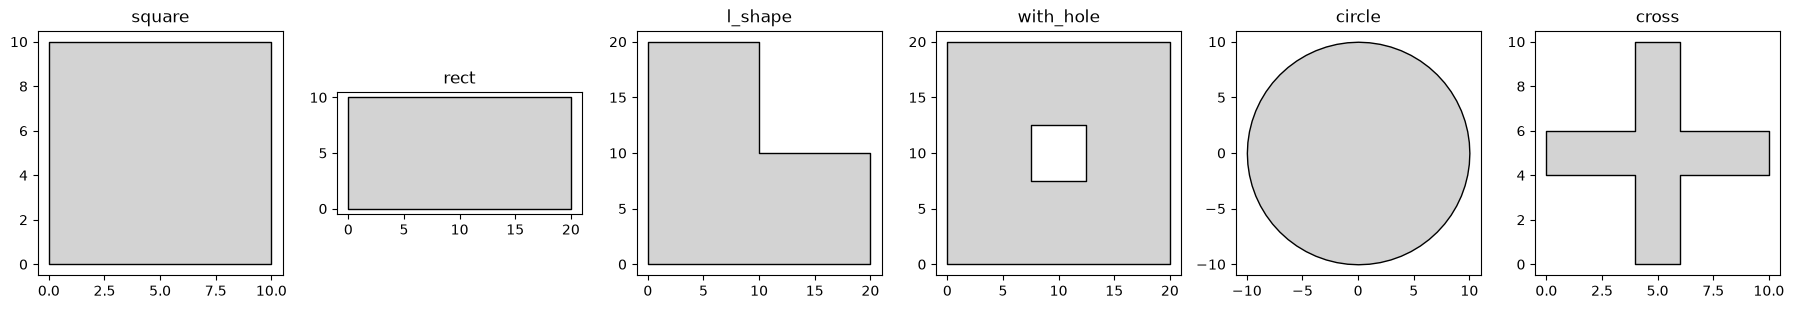

In [2]:
square = gdf_of(square_polygon())
rect = gdf_of(rect_polygon())
l_shape = gdf_of(l_shape_polygon())
with_hole = gdf_of(square_with_hole_polygon())
circle = gdf_of(circle_polygon())
cross = gdf_of(thin_cross_polygon())

shapes = {"square": square, "rect": rect, "l_shape": l_shape,
          "with_hole": with_hole, "circle": circle, "cross": cross}

fig, axes = plt.subplots(1, len(shapes), figsize=(3 * len(shapes), 3))
for ax, (name, g) in zip(axes, shapes.items()):
    g.plot(ax=ax, facecolor="lightgrey", edgecolor="black")
    ax.set_title(name)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Code-independent indices

- `polsby_popper` = 4*pi*A / P^2 (1.0 = perfect circle)
- `inertia_circle_ratio` = I_z(equal-area circle) / I_z(footprint)
- `convex_hull_irregularity` = (hull_area - footprint_area) / footprint_area (0 = convex)

In [3]:
import pandas as pd

rows = []
for name, g in shapes.items():
    rows.append({
        "shape": name,
        "polsby_popper": shape.polsby_popper(g)[0],
        "inertia_circle_ratio": shape.inertia_circle_ratio(g)[0],
        "convex_hull_irregularity": shape.convex_hull_irregularity(g)[0],
    })
df = pd.DataFrame(rows).set_index("shape")
df


,polsby_popper,inertia_circle_ratio,convex_hull_irregularity
shape,,,
square,0.785398,0.954930,0.000000e+00
rect,0.698132,0.763944,0.000000e+00
l_shape,0.589049,0.781306,1.666667e-01
with_hole,0.785398,0.836028,0.000000e+00
circle,0.999197,0.999999,-7.249168e-16
cross,0.282743,0.599607,8.888889e-01


### Slenderness — `bbox` (exact for rectangles) vs `inertia` (paper eq. 2)

In [4]:
for name, g in shapes.items():
    print(f"{name:12s} bbox={shape.slenderness.bbox(g)[0]:.3f}"
          f"   inertia={shape.slenderness.inertia(g)[0]:.3f}")


square       bbox=1.000   inertia=1.000
rect         bbox=2.000   inertia=2.000
l_shape      bbox=1.000   inertia=1.464
with_hole    bbox=1.000   inertia=1.000
circle       bbox=1.000   inertia=1.000
cross        bbox=1.000   inertia=1.000


### Eurocode 8

Four parameters: `eccentricityRatio` (<=0.30), `radiusRatio` (>=1.0),
`compactness` (>=0.95). Each has a `compliance_EC8_*` column (0-100).

In [5]:
ec8 = shape.EC8(l_shape)
ec8[[c for c in ec8.columns if c != "geometry"]]


,EC8_eccentricityRatio,compliance_EC8_eccentricityRatio,EC8_radiusRatio,compliance_EC8_radiusRatio,EC8_compactness,compliance_EC8_compactness
0,0.184908,100,0.219281,0,0.833333,0


### ASCE 7, GNDT Level II, NTC-23 — setback ratios on an asymmetric shape

`asymmetric_l_shape_polygon` is a 30x20 rectangle minus a 20x8 notch,
built so `L1 != L2` and the notch is not symmetric under any axis swap —
its setback ratio has a known value of 0.4 (`min(b1/L1, b2/L2)`).

In [6]:
asymmetric = gdf_of(asymmetric_l_shape_polygon())

print("ASCE7 setback ratio  (expect 0.4):", shape.ASCE7(asymmetric)["ASCE7_setbackRatio"].iloc[0])
print("NTC23 setback ratio  (expect 0.4):", shape.NTC23(asymmetric)["NTC23_setbackRatio"].iloc[0])
print("GNDTII beta2         (expect 0.4):", shape.GNDTII(asymmetric)["GNDTII_beta2_setbackRatio"].iloc[0])


ASCE7 setback ratio  (expect 0.4): 0.39999999999998004
NTC23 setback ratio  (expect 0.4): 0.39999999999998004
GNDTII beta2         (expect 0.4): 0.39999999999998004


### Batch call — shared work computed once

`shape(gdf, columns)` computes any mix of columns across norms, sharing
the expensive bbox/inertia computations.

In [7]:
batch = shape(l_shape, ["EC8_compactness", "ASCE7_setbackRatio", "slenderness_bbox", "polsby_popper"])
batch


,geometry,EC8_compactness,ASCE7_setbackRatio,slenderness_bbox,polsby_popper
0,"POLYGON ((20 0, 0 0, 0 20, 10 20, 10 10, 20 10...",0.833333,0.5,1.0,0.589049


## Part 2 — Real data: the three pilot areas

Same indices, run on the actual digitised footprints from San José (Costa
Rica), Guatemala City, and Santo Domingo (Dominican Republic).

In [8]:
CITY_FILES = {
    "san_jose": "data/san_jose_pilot_region.gpkg",
    "guatemala": "data/guatemala_pilot_region.gpkg",
    "santo_domingo": "data/santo_domingo_pilot_region.gpkg",
}

def load_city(path):
    gdf = gpd.read_file(path)
    gdf = gdf[gdf.geometry.notna() & ~gdf.geometry.is_empty].reset_index(drop=True)
    if (gdf.geometry.type == "MultiPolygon").any():
        gdf = gdf.explode(index_parts=False).reset_index(drop=True)
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    gdf.geometry = gdf.geometry.make_valid()
    gdf = gdf[gdf.geometry.type == "Polygon"].reset_index(drop=True)
    return gdf


In [9]:
results = {}
for city, path in CITY_FILES.items():
    gdf = load_city(path)
    gdf["polsby_popper"] = shape.polsby_popper(gdf)
    gdf["inertia_circle_ratio"] = shape.inertia_circle_ratio(gdf)
    gdf["convex_hull_irregularity"] = shape.convex_hull_irregularity(gdf)
    gdf = shape.slenderness(gdf)

    ec8 = shape.EC8(gdf)
    asce7 = shape.ASCE7(gdf)
    gndt = shape.GNDTII(gdf)
    cscr = shape.CSCR2010(gdf)
    ntc23 = shape.NTC23(gdf)
    for df, prefix in [(ec8, "EC8_"), (asce7, "ASCE7_"), (gndt, "GNDTII_"),
                        (cscr, "CSCR2010_"), (ntc23, "NTC23_")]:
        for col in df.columns:
            if col.startswith(prefix) or col.startswith(f"compliance_{prefix}"):
                gdf[col] = df[col]

    results[city] = gdf
    print(f"{city:15s} {len(gdf):5d} footprints, {len(gdf.columns)} columns")


san_jose          911 footprints, 43 columns


guatemala         435 footprints, 43 columns


santo_domingo    1463 footprints, 43 columns


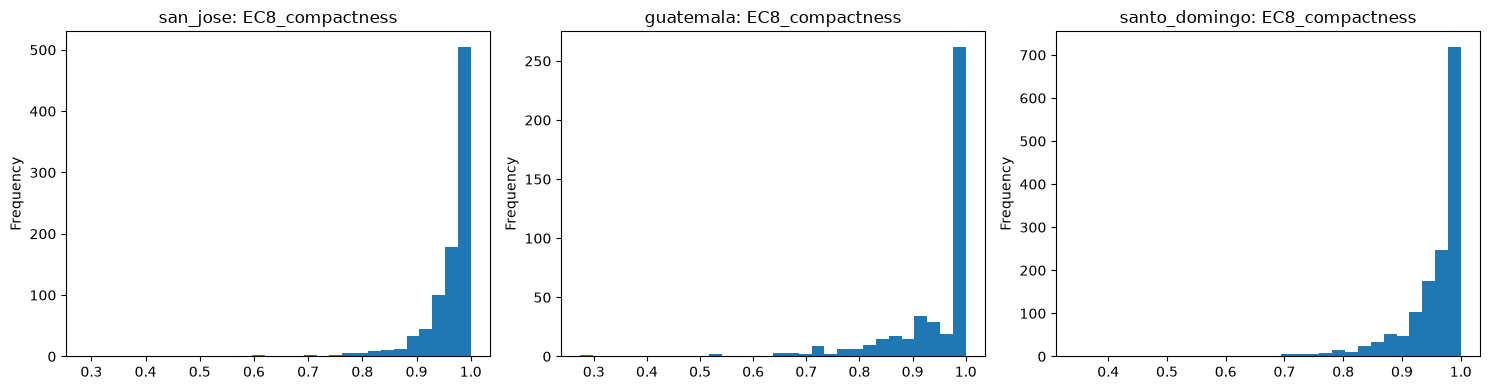

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (city, gdf) in zip(axes, results.items()):
    gdf["EC8_compactness"].plot.hist(ax=ax, bins=30)
    ax.set_title(f"{city}: EC8_compactness")
plt.tight_layout()
plt.show()


## Result

One GeoDataFrame per city, each carrying the shape indices. Suggested
columns to visualise on a map:

- `EC8_compactness`, `EC8_eccentricityRatio`, `EC8_radiusRatio`
- `slenderness_bbox`
- `ASCE7_setbackRatio`, `ASCE7_holeRatio`
- `polsby_popper`


In [11]:
san_jose_gdf = results["san_jose"]
guatemala_gdf = results["guatemala"]
santo_domingo_gdf = results["santo_domingo"]

map_columns = [
    "id", "EC8_compactness", "EC8_eccentricityRatio", "EC8_radiusRatio",
    "slenderness_bbox", "ASCE7_setbackRatio", "ASCE7_holeRatio",
    "polsby_popper", "geometry",
]
san_jose_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,...,GNDTII_beta4_eccentricityRatio,compliance_GNDTII_beta4_eccentricityRatio,GNDTII_beta6_setbackSlenderness,compliance_GNDTII_beta6_setbackSlenderness,CSCR2010_eccentricityRatio,compliance_CSCR2010_eccentricityRatio,NTC23_setbackRatio,compliance_NTC23_setbackRatio,NTC23_holeRatio,compliance_NTC23_holeRatio
0,1000009.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817592.282 1098630.841, 817583.141 1...",...,0.019681,100,0.000000,0,0.018580,100,0.000000,100,0.0,100
1,1219.0,san_jose,6.0,2.0,1975,pre_code,M,M,metallic,"POLYGON ((817554.533 1098638.188, 817559.35 10...",...,0.000698,100,0.000000,0,0.000198,100,0.000000,100,0.0,100
2,1000010.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817593.338 1098634.876, 817591.389 1...",...,0.004051,100,0.000000,0,0.001297,100,0.000000,100,0.0,100
3,1221.0,san_jose,6.0,2.0,1985,low_code,M,M,bright_concrete,"POLYGON ((817509.464 1098646.298, 817509.417 1...",...,0.001818,100,73.123485,100,0.000716,100,0.027276,100,0.0,100
4,1222.0,san_jose,6.0,2.0,1988,medium_code,M,M,metallic,"POLYGON ((817484.519 1098643.546, 817484.505 1...",...,0.019819,100,1.294667,100,0.008043,100,0.337829,100,0.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
906,1000029.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,metallic,"POLYGON ((817487.513 1099327.718, 817489.214 1...",...,0.000463,100,0.000000,0,0.000134,100,0.000000,100,0.0,100
907,1000030.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817491.914 1098875.344, 817490.37 10...",...,0.000555,100,0.000000,0,0.000275,100,0.000000,100,0.0,100
908,1000031.0,san_jose,NaN,NaN,1985,low_code,NaN,NaN,metallic,"POLYGON ((817594.418 1098785.886, 817594.699 1...",...,0.000407,100,53.107216,100,0.000253,100,0.018521,100,0.0,100
909,1000032.0,san_jose,NaN,NaN,1975,pre_code,NaN,NaN,dark_shadow,"POLYGON ((817661.05 1098730.134, 817658.341 10...",...,0.011125,100,0.000000,0,0.002882,100,0.000000,100,0.0,100


In [12]:
guatemala_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,...,GNDTII_beta4_eccentricityRatio,compliance_GNDTII_beta4_eccentricityRatio,GNDTII_beta6_setbackSlenderness,compliance_GNDTII_beta6_setbackSlenderness,CSCR2010_eccentricityRatio,compliance_CSCR2010_eccentricityRatio,NTC23_setbackRatio,compliance_NTC23_setbackRatio,NTC23_holeRatio,compliance_NTC23_holeRatio
0,7,guatemala,21.0,7.0,1985,pre_code,CR,CR,metallic,"POLYGON ((767790.902 1620302.842, 767786.491 1...",...,0.023742,100,2.165576,100,0.012467,100,0.296497,100,0.000000,100
1,8,guatemala,6.0,2.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767692.792 1620324.14, 767686.494 16...",...,0.010269,100,3.412135,100,0.008417,100,0.202925,100,0.000000,100
2,9,guatemala,18.0,6.0,1985,pre_code,CR,CR,bright_concrete,"POLYGON ((767653.981 1620317.212, 767650.617 1...",...,0.017435,100,0.000000,0,0.008316,100,0.000000,100,0.251351,100
3,10,guatemala,9.0,3.0,1985,pre_code,CR,CR,dark_shadow,"POLYGON ((767631.691 1620320.309, 767627.553 1...",...,0.000584,100,73.345185,100,0.000349,100,0.013298,100,0.000000,100
4,53,guatemala,3.0,1.0,1985,pre_code,M,M,bright_concrete,"POLYGON ((767736.621 1620273.206, 767737.434 1...",...,0.000498,100,0.000000,0,0.000203,100,0.000000,100,0.000000,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
430,1000020,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767967.054 1620766.917, 767967.159 1...",...,0.032144,100,1.436984,100,0.012651,100,0.533882,0,0.000000,100
431,1000021,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767957.402 1620784.045, 767971.325 1...",...,0.001506,100,17.451708,100,0.001162,100,0.005442,100,0.000000,100
432,1000024,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767742.538 1620785.376, 767743.107 1...",...,0.000317,100,0.000000,0,0.000172,100,0.000000,100,0.000000,100
433,1000001,guatemala,NaN,NaN,1985,pre_code,NaN,NaN,NaN,"POLYGON ((767743.478 1620338.287, 767750.941 1...",...,0.000206,100,64.730736,100,0.000102,100,0.006837,100,0.000000,100


In [13]:
santo_domingo_gdf


,id,city,height,n_storeys,year,code_quality,structural_system,simplified_structural_system,roof,geometry,...,GNDTII_beta4_eccentricityRatio,compliance_GNDTII_beta4_eccentricityRatio,GNDTII_beta6_setbackSlenderness,compliance_GNDTII_beta6_setbackSlenderness,CSCR2010_eccentricityRatio,compliance_CSCR2010_eccentricityRatio,NTC23_setbackRatio,compliance_NTC23_setbackRatio,NTC23_holeRatio,compliance_NTC23_holeRatio
0,756,santo_domingo,6.0,2.0,1985,low_code,M,M,metallic,"POLYGON ((400755.503 2041946.512, 400763.567 2...",...,0.021504,100,2.164672,100,0.009030,100,0.296443,100,0.0,100
1,1448,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400752.768 2041786.239, 400747.871 2...",...,0.004699,100,5.477695,100,0.003568,100,0.083000,100,0.0,100
2,783,santo_domingo,3.0,1.0,1985,low_code,M,M,metallic,"POLYGON ((400728.96 2042022.949, 400740.02 204...",...,0.001708,100,8.183667,100,0.001255,100,0.031169,100,0.0,100
3,506,santo_domingo,9.0,3.0,1985,low_code,M,M,metallic,"POLYGON ((400621.845 2042180.408, 400624.684 2...",...,0.007019,100,3.738565,100,0.006067,100,0.114906,100,0.0,100
4,952,santo_domingo,27.0,9.0,1985,low_code,CR,CR,asphalt,"POLYGON ((399942.413 2041384.087, 399943.943 2...",...,0.064830,100,0.401228,50,0.044375,100,0.516223,0,0.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1458,411,santo_domingo,NaN,NaN,1985,low_code,NaN,NaN,NaN,"POLYGON ((400660.873 2042109.183, 400673.948 2...",...,0.081985,100,0.741549,100,0.030951,100,0.474184,0,0.0,100
1459,410,santo_domingo,9.0,3.0,1985,low_code,M,M,NaN,"POLYGON ((400662.197 2042101.872, 400655.932 2...",...,0.009872,100,6.623781,100,0.006924,100,0.112397,100,0.0,100
1460,409,santo_domingo,12.0,4.0,1989,low_code,M,M,NaN,"POLYGON ((400685.397 2042099.449, 400695.452 2...",...,0.009766,100,0.865325,100,0.004814,100,0.340596,100,0.0,100
1461,408,santo_domingo,15.0,5.0,1985,low_code,M,M,NaN,"POLYGON ((400698.257 2042029.509, 400694.637 2...",...,0.010097,100,12.804246,100,0.007700,100,0.118023,100,0.0,100


In [14]:
map_columns


['id',
 'EC8_compactness',
 'EC8_eccentricityRatio',
 'EC8_radiusRatio',
 'slenderness_bbox',
 'ASCE7_setbackRatio',
 'ASCE7_holeRatio',
 'polsby_popper',
 'geometry']